<a href="https://colab.research.google.com/github/JakeEisner/ECON3916-Statistical-Machine-Learning/blob/main/Lab%2015/%5BLab_15%5D_Lab%5D_From_Regression_to_Machine_Learning_%E2%80%94_The_Bias_Variance_Tradeoff.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import make_pipeline
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
print('Setup complete ✓')

Setup complete ✓


<Figure size 700x500 with 0 Axes>

<Figure size 700x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

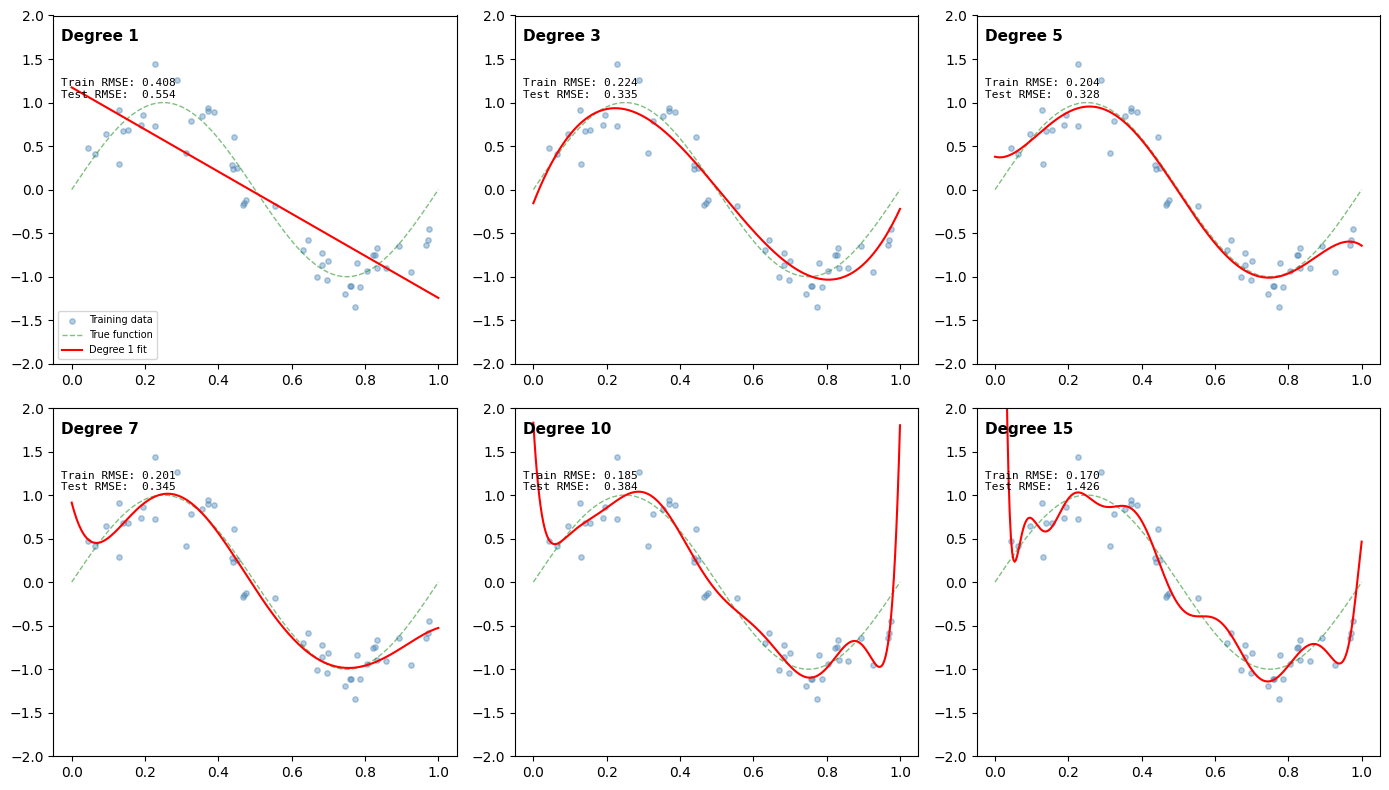

In [57]:
degrees = [1, 3, 5, 7, 10, 15]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for idx, d in enumerate(degrees):
    ax = axes[idx]
    model = make_pipeline(
        PolynomialFeatures(d, include_bias=False),
        LinearRegression()
    )
    model.fit(x_train.reshape(-1, 1), y_train)
    y_pred_plot = model.predict(x_plot.reshape(-1, 1))

    train_rmse = np.sqrt(mean_squared_error(
        y_train, model.predict(x_train.reshape(-1, 1))))
    test_rmse = np.sqrt(mean_squared_error(
        y_test, model.predict(x_test.reshape(-1, 1))))

    ax.scatter(x_train, y_train, alpha=0.4, s=15, color='steelblue',
               label='Training data')
    ax.plot(x_plot, true_function(x_plot), 'g--', alpha=0.5,
            linewidth=1, label='True function')
    ax.plot(x_plot, y_pred_plot, 'r-', linewidth=1.5,
            label=f'Degree {d} fit')
    ax.set_ylim(-2, 2)
    ax.text(0.02, 0.96, f'Degree {d}', transform=ax.transAxes,
            fontsize=11, fontweight='bold', va='top')
    ax.text(0.02, 0.82,
            f'Train RMSE: {train_rmse:.3f}\nTest RMSE:  {test_rmse:.3f}',
            transform=ax.transAxes, fontsize=8, va='top',
            fontfamily='monospace')
    if idx == 0:
        ax.legend(fontsize=7, loc='lower left')

plt.tight_layout()
plt.show()

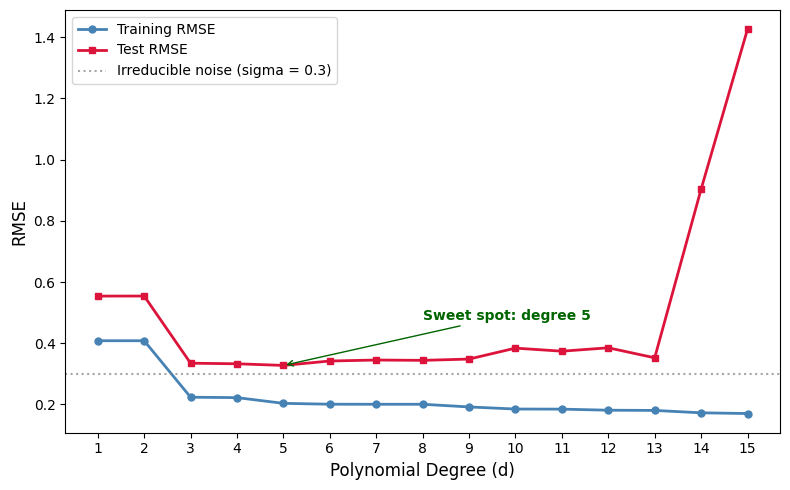

In [58]:
all_degrees = range(1, 16)
train_errors = []
test_errors = []

for d in all_degrees:
    model = make_pipeline(
        PolynomialFeatures(d, include_bias=False),
        LinearRegression()
    )
    model.fit(x_train.reshape(-1, 1), y_train)
    train_rmse = np.sqrt(mean_squared_error(
        y_train, model.predict(x_train.reshape(-1, 1))))
    test_rmse = np.sqrt(mean_squared_error(
        y_test, model.predict(x_test.reshape(-1, 1))))
    train_errors.append(train_rmse)
    test_errors.append(test_rmse)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(all_degrees), train_errors, 'o-', color='steelblue',
        linewidth=2, markersize=5, label='Training RMSE')
ax.plot(list(all_degrees), test_errors, 's-', color='crimson',
        linewidth=2, markersize=5, label='Test RMSE')
ax.axhline(y=noise_std, color='gray', linestyle=':', alpha=0.7,
           label=f'Irreducible noise (sigma = {noise_std})')

best_degree = list(all_degrees)[np.argmin(test_errors)]
best_test_rmse = min(test_errors)
ax.annotate(f'Sweet spot: degree {best_degree}',
            xy=(best_degree, best_test_rmse),
            xytext=(best_degree + 3, best_test_rmse + 0.15),
            arrowprops=dict(arrowstyle='->', color='darkgreen'),
            fontsize=10, color='darkgreen', fontweight='bold')

ax.set_xlabel('Polynomial Degree (d)', fontsize=12)
ax.set_ylabel('RMSE', fontsize=12)
ax.set_xticks(list(all_degrees))
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

In [59]:
def manual_kfold_cv(x, y, degree, k=5):
    """
    Perform k-fold cross-validation for polynomial regression.

    Parameters
    ----------
    x : np.ndarray, shape (n,)
    y : np.ndarray, shape (n,)
    degree : int
    k : int

    Returns
    -------
    float : Mean CV RMSE
    np.ndarray : Per-fold RMSE values
    """
    n = len(x)
    indices = np.arange(n)
    np.random.shuffle(indices)
    folds = np.array_split(indices, k)

    fold_errors = []

    for i in range(k):
        # Create test and train indices for this fold
        test_idx = fold[i]
        train_idx = np.concatenate(
            [folds[j] for j in range(k) if j != i]
        )

        # Split data
        x_fold_train, y_fold_train = x[train_idx], y[train_idx]
        x_fold_test, y_fold_test = x[test_idx], y[test_idx]

        # Fit polynomial model on training fold
        model = make_pipeline(
            PolynomialFeatures(degree, include_bias=False),
            LinearRegression()
        )
        model.fit(x_fold_train.reshape(-1,1), y_fold_train)

        # Predict on test fold and compute RMSE
        y_pred = model.predict(x_fold_test.reshape(-1,1))
        fold_rmse = np.sqrt(mean_squared_error(
            y_fold_test, y_pred))
        fold_errors.append(fold_rmse)

    fold_errors = np.array(fold_errors)
    return fold_errors.mean(), fold_errors

In [60]:
from sklearn.model_selection import cross_val_score

model_d3 = make_pipeline(
    PolynomialFeatures(3, include_bias=False),
    LinearRegression()
)

# cross_val_score returns NEGATIVE MSE (sklearn convention)
cv_scores = cross_val_score(
    model_d3, x_train.reshape(-1, 1), y_train,
    cv=5, scoring='neg_mean_squared_error'
)
cv_rmse = np.sqrt(-cv_scores)

print(f'sklearn 5-fold CV RMSE (degree 3): '
      f'{cv_rmse.mean():.4f} +/- {cv_rmse.std():.4f}')
print(f'Per-fold RMSE: {cv_rmse}')

sklearn 5-fold CV RMSE (degree 3): 0.2740 +/- 0.0528
Per-fold RMSE: [0.35055828 0.31701548 0.25271955 0.20309551 0.24653546]


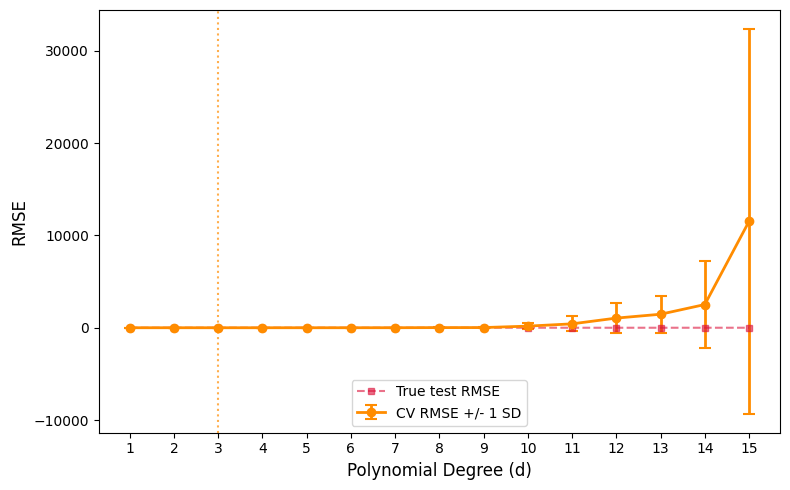

CV-selected degree: 3
True optimal degree: 5


In [61]:
all_degrees = range(1, 16)
cv_means = []
cv_stds = []

for d in all_degrees:
    model = make_pipeline(
        PolynomialFeatures(d, include_bias=False),
        LinearRegression()
    )
    scores = cross_val_score(
        model, x_train.reshape(-1, 1), y_train,
        cv=5, scoring='neg_mean_squared_error'
    )
    rmse_scores = np.sqrt(-scores)
    cv_means.append(rmse_scores.mean())
    cv_stds.append(rmse_scores.std())

cv_means = np.array(cv_means)
cv_stds = np.array(cv_stds)

fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(list(all_degrees), cv_means, yerr=cv_stds,
            fmt='o-', color='darkorange', linewidth=2,
            markersize=6, capsize=4, capthick=1.5,
            label='CV RMSE +/- 1 SD')
ax.plot(list(all_degrees), test_errors, 's--', color='crimson',
        linewidth=1.5, markersize=4, alpha=0.6,
        label='True test RMSE')

cv_best_degree = list(all_degrees)[np.argmin(cv_means)]
ax.axvline(x=cv_best_degree, color='darkorange', linestyle=':',
           alpha=0.7)

ax.set_xlabel('Polynomial Degree (d)', fontsize=12)
ax.set_ylabel('RMSE', fontsize=12)
ax.set_xticks(list(all_degrees))
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(f'CV-selected degree: {cv_best_degree}')
print(f'True optimal degree: {best_degree}')

In [62]:
from sklearn.datasets import fetch_openml

ames = fetch_openml(name='house_prices', version=1,
                    as_frame=True, parser='auto')
df_ames = ames.data.copy()
df_ames['SalePrice'] = ames.target.astype(float)

numeric_cols = df_ames.select_dtypes(
    include=[np.number]).columns.tolist()
numeric_cols.remove('SalePrice')
df_numeric = df_ames[numeric_cols + ['SalePrice']].dropna()

X_ames = df_numeric[numeric_cols].values
y_ames = df_numeric['SalePrice'].values

print(f'Ames Housing: {X_ames.shape[0]} observations, '
      f'{X_ames.shape[1]} numeric features')
print(f'p/n ratio: {X_ames.shape[1] / X_ames.shape[0]:.3f}')

Ames Housing: 1121 observations, 37 numeric features
p/n ratio: 0.033


In [63]:
from sklearn.preprocessing import StandardScaler

# Approach 1: Kitchen sink - all features
kitchen_sink = make_pipeline(StandardScaler(), LinearRegression())

cv_kitchen = cross_val_score(
    kitchen_sink, X_ames, y_ames,
    cv=5, scoring='neg_mean_squared_error'
)
rmse_kitchen = np.sqrt(-cv_kitchen)
print(f'Kitchen sink (all {X_ames.shape[1]} features):')
print(f'  CV RMSE: {rmse_kitchen.mean():,.0f} '
      f'+/- {rmse_kitchen.std():,.0f}')

# Approach 2: Top 5 features by correlation
correlations = df_numeric.corr()['SalePrice'].drop(
    'SalePrice').abs().sort_values(ascending=False)
top_5_features = correlations.head(5).index.tolist()
print(f'\nTop 5 features: {top_5_features}')

X_top5 = df_numeric[top_5_features].values
simple_model = make_pipeline(StandardScaler(), LinearRegression())

cv_simple = cross_val_score(
    simple_model, X_top5, y_ames,
    cv=5, scoring='neg_mean_squared_error'
)
rmse_simple = np.sqrt(-cv_simple)
print(f'\nSimple model (top 5 features):')
print(f'  CV RMSE: {rmse_simple.mean():,.0f} '
      f'+/- {rmse_simple.std():,.0f}')

Kitchen sink (all 37 features):
  CV RMSE: 38,871 +/- 8,515

Top 5 features: ['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea', 'TotalBsmtSF']

Simple model (top 5 features):
  CV RMSE: 41,986 +/- 7,397


📝 Written Response — Answer in your notebook in complete sentences.
Reflection Question: Which model would you deploy to predict house prices for new listings? Why? Use the concepts from today's lecture (bias, variance, generalization gap, CV) in your answer.


I would deploy the simpler model with the top 5 features. Even though the kitchen-sink model has a higher training R², its worse CV RMSE shows it’s overfitting and not generalizing well. It has high variance and a bigger generalization gap.

The simpler model has a bit more bias, but a lower CV RMSE, which means it performs better on new data. Since CV RMSE reflects out-of-sample performance, it’s more important than training R² here.

Overall, the simpler model is better because it balances bias and variance and gives more reliable predictions for new listings.


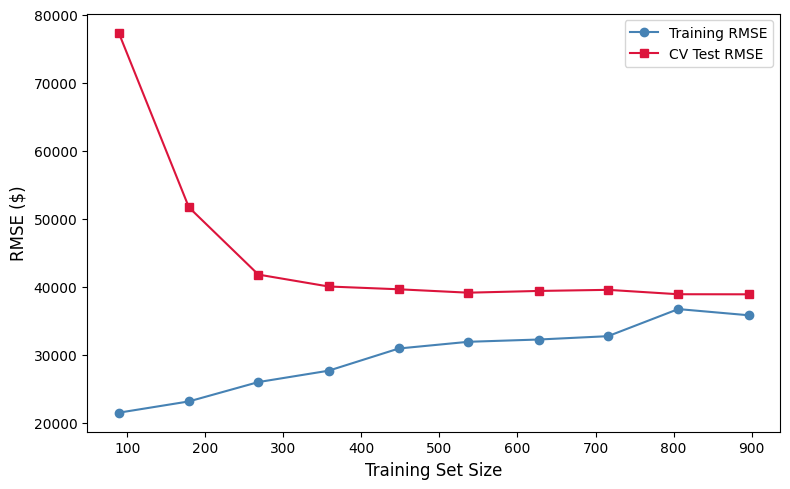

In [64]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    make_pipeline(StandardScaler(), LinearRegression()),
    X_ames, y_ames,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5,
    scoring='neg_mean_squared_error'
)

train_rmse_lc = np.sqrt(-train_scores).mean(axis=1)
test_rmse_lc = np.sqrt(-test_scores).mean(axis=1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(train_sizes, train_rmse_lc, 'o-', color='steelblue',
        label='Training RMSE')
ax.plot(train_sizes, test_rmse_lc, 's-', color='crimson',
        label='CV Test RMSE')
ax.set_xlabel('Training Set Size', fontsize=12)
ax.set_ylabel('RMSE ($)', fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()


In [65]:
!pip install streamlit

In [66]:
import numpy as np
import streamlit as st
import matplotlib.pyplot as plt

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error


# --------------------------------------------------
# Page setup
# --------------------------------------------------
st.set_page_config(page_title="Bias-Variance Tradeoff Dashboard", layout="wide")

st.title("Bias-Variance Tradeoff for Polynomial Regression")
st.markdown(
    "Explore how model complexity changes fit quality, generalization error, "
    "and the bias-variance tradeoff for data generated from "
    r"$y = \sin(2\pi x) + \varepsilon$."
)


# --------------------------------------------------
# Core functions
# --------------------------------------------------
def true_function(x):
    return np.sin(2 * np.pi * x)


def generate_data(n_train, n_test=200, sigma=0.3, seed=42):
    rng = np.random.default_rng(seed)

    x_train = np.sort(rng.uniform(0, 1, n_train))
    y_train = true_function(x_train) + rng.normal(0, sigma, n_train)

    x_test = np.sort(rng.uniform(0, 1, n_test))
    y_test = true_function(x_test) + rng.normal(0, sigma, n_test)

    x_plot = np.linspace(0, 1, 300)

    return x_train, y_train, x_test, y_test, x_plot


def fit_model(x, y, degree):
    model = make_pipeline(
        PolynomialFeatures(degree, include_bias=False),
        LinearRegression()
    )
    model.fit(x.reshape(-1, 1), y)
    return model


def compute_complexity_curve(x_train, y_train, x_test, y_test, max_degree=15):
    train_rmse = []
    test_rmse = []

    for d in range(1, max_degree + 1):
        model = fit_model(x_train, y_train, d)

        yhat_train = model.predict(x_train.reshape(-1, 1))
        yhat_test = model.predict(x_test.reshape(-1, 1))

        train_rmse.append(np.sqrt(mean_squared_error(y_train, yhat_train)))
        test_rmse.append(np.sqrt(mean_squared_error(y_test, yhat_test)))

    return np.array(train_rmse), np.array(test_rmse)


@st.cache_data(show_spinner=False)
def bootstrap_bias_variance(n_train, sigma, n_boot=100, max_degree=15, seed=123):
    rng = np.random.default_rng(seed)
    x_grid = np.linspace(0, 1, 200)
    f_true = true_function(x_grid)

    bias2_list = []
    variance_list = []
    mse_list = []

    for d in range(1, max_degree + 1):
        preds = []

        for _ in range(n_boot):
            x_boot = np.sort(rng.uniform(0, 1, n_train))
            y_boot = true_function(x_boot) + rng.normal(0, sigma, n_train)

            model = fit_model(x_boot, y_boot, d)
            pred = model.predict(x_grid.reshape(-1, 1))
            preds.append(pred)

        preds = np.array(preds)  # shape: (n_boot, len(x_grid))

        mean_pred = preds.mean(axis=0)
        variance = preds.var(axis=0).mean()
        bias2 = ((mean_pred - f_true) ** 2).mean()

        # Expected test MSE ≈ Bias^2 + Variance + sigma^2
        mse = ((preds - f_true.reshape(1, -1)) ** 2).mean() + sigma**2

        bias2_list.append(bias2)
        variance_list.append(variance)
        mse_list.append(mse)

    return x_grid, np.array(bias2_list), np.array(variance_list), np.array(mse_list)


# --------------------------------------------------
# Sidebar controls
# --------------------------------------------------
st.sidebar.header("Controls")

degree = st.sidebar.slider("Polynomial degree", min_value=1, max_value=15, value=5, step=1)
sigma = st.sidebar.slider("Noise level (sigma)", min_value=0.1, max_value=1.0, value=0.3, step=0.1)
n_train = st.sidebar.slider("Number of training points", min_value=20, max_value=200, value=50, step=10)

st.sidebar.markdown("---")
st.sidebar.markdown(
    f"""
**Current settings**
- Degree: `{degree}`
- Sigma: `{sigma:.1f}`
- Training points: `{n_train}`
"""
)


# --------------------------------------------------
# Generate data
# --------------------------------------------------
x_train, y_train, x_test, y_test, x_plot = generate_data(
    n_train=n_train,
    n_test=200,
    sigma=sigma,
    seed=42
)

model = fit_model(x_train, y_train, degree)
y_plot_pred = model.predict(x_plot.reshape(-1, 1))
y_train_pred = model.predict(x_train.reshape(-1, 1))
y_test_pred = model.predict(x_test.reshape(-1, 1))

selected_train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
selected_test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

train_curve, test_curve = compute_complexity_curve(x_train, y_train, x_test, y_test, max_degree=15)


# --------------------------------------------------
# Top row: fit plot + complexity curve
# --------------------------------------------------
col1, col2 = st.columns(2)

with col1:
    st.subheader("Polynomial Fit")

    fig1, ax1 = plt.subplots(figsize=(7, 5))
    ax1.scatter(x_train, y_train, alpha=0.65, s=30, label="Training data")
    ax1.plot(x_plot, true_function(x_plot), linestyle="--", linewidth=2, label="True function")
    ax1.plot(x_plot, y_plot_pred, linewidth=2, label=f"Degree {degree} fit")
    ax1.set_xlabel("x")
    ax1.set_ylabel("y")
    ax1.set_ylim(-2.5, 2.5)
    ax1.legend()
    ax1.set_title(f"Selected Degree = {degree}")
    st.pyplot(fig1, clear_figure=True)

    st.markdown(
        f"""
**Selected model performance**
- Training RMSE: `{selected_train_rmse:.3f}`
- Test RMSE: `{selected_test_rmse:.3f}`
"""
    )

with col2:
    st.subheader("Complexity Curve")

    fig2, ax2 = plt.subplots(figsize=(7, 5))
    degrees = np.arange(1, 16)

    ax2.plot(degrees, train_curve, marker="o", linewidth=2, label="Training RMSE")
    ax2.plot(degrees, test_curve, marker="s", linewidth=2, label="Test RMSE")
    ax2.axvline(degree, linestyle="--", linewidth=2, label=f"Selected degree = {degree}")
    ax2.axhline(sigma, linestyle=":", linewidth=1.5, label=f"Irreducible noise = {sigma:.1f}")

    best_degree = degrees[np.argmin(test_curve)]
    ax2.set_xlabel("Polynomial Degree")
    ax2.set_ylabel("RMSE")
    ax2.set_xticks(degrees)
    ax2.legend()
    ax2.set_title(f"Best test RMSE at degree {best_degree}")
    st.pyplot(fig2, clear_figure=True)


# --------------------------------------------------
# Bottom row: bias-variance decomposition
# --------------------------------------------------
st.subheader("Bias-Variance Decomposition (Bootstrap Estimate)")

with st.spinner("Computing bootstrap bias-variance decomposition..."):
    x_grid, bias2_vals, variance_vals, mse_vals = bootstrap_bias_variance(
        n_train=n_train,
        sigma=sigma,
        n_boot=100,
        max_degree=15,
        seed=123
    )

noise_vals = np.full(15, sigma**2)
reconstructed_mse = bias2_vals + variance_vals + noise_vals

fig3, ax3 = plt.subplots(figsize=(10, 5))
degrees = np.arange(1, 16)

ax3.plot(degrees, bias2_vals, marker="o", linewidth=2, label="Bias²")
ax3.plot(degrees, variance_vals, marker="s", linewidth=2, label="Variance")
ax3.plot(degrees, mse_vals, marker="^", linewidth=2, label="Estimated MSE")
ax3.plot(degrees, reconstructed_mse, linestyle="--", linewidth=2, label="Bias² + Variance + sigma²")
ax3.axvline(degree, linestyle="--", linewidth=2, label=f"Selected degree = {degree}")

ax3.set_xlabel("Polynomial Degree")
ax3.set_ylabel("Error")
ax3.set_xticks(degrees)
ax3.legend(ncol=2)
ax3.set_title("Bootstrap Bias-Variance Tradeoff")
st.pyplot(fig3, clear_figure=True)

idx = degree - 1
st.markdown(
    f"""
**At degree {degree}:**
- Bias²: `{bias2_vals[idx]:.4f}`
- Variance: `{variance_vals[idx]:.4f}`
- Noise variance (sigma²): `{sigma**2:.4f}`
- Bias² + Variance + sigma²: `{reconstructed_mse[idx]:.4f}`
- Estimated MSE: `{mse_vals[idx]:.4f}`
"""
)

st.caption(
    "The decomposition will not match perfectly because it is estimated numerically with finite bootstrap samples, "
    "but it should be close."
)

2026-03-25 22:36:50.561 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-25 22:36:50.562 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-25 22:36:50.563 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-25 22:36:50.564 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-25 22:36:50.565 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-25 22:36:50.566 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-25 22:36:50.567 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-25 22:36:50.570 No runtime found, using MemoryCacheStorageManager
2026-03-25 22:36:50.577 Thread 'MainThread':

DeltaGenerator()